In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TRAIN_DATASET_DIR = "./learn_dataset_single_object"  # 学習: 単一物体
TEST_DATASET_DIR  = "./learn_dataset_fixed_angle"     # テスト: 2物体同時
TRAIN_META_CSV = os.path.join(TRAIN_DATASET_DIR, "metadata.csv")
TEST_META_CSV  = os.path.join(TEST_DATASET_DIR,  "metadata.csv")
MODEL_PATH = "./best_detector_agnostic.pt"

N_FIXED      = 10
FIXED_ANGLES = np.linspace(-5, 5, N_FIXED)  # 角度グリッド [度]
SIGMA_ANGLE  = 0.3                           # 角度方向Gaussianの標準偏差 [度]

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
EPOCHS     = 50
LR         = 1e-3

D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
print("TRAIN_META_CSV exists:", os.path.exists(TRAIN_META_CSV))
print("TEST_META_CSV  exists:", os.path.exists(TEST_META_CSV))
print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

torch.cuda.empty_cache()
print(f"allocated: {torch.cuda.memory_allocated()/1024**2:.0f} MB")
print(f"reserved:  {torch.cuda.memory_reserved()/1024**2:.0f} MB")

DEVICE: cuda
TRAIN_META_CSV exists: True
TEST_META_CSV  exists: True
True
NVIDIA GeForce RTX 3060 Ti
allocated: 0 MB
reserved:  0 MB


In [3]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [4]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [5]:
class MultiTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)
        # 学習開始前に全データをRAMに読み込む（毎バッチのディスクI/Oを排除）
        self.samples = []
        print(f"データ読み込み中... ({len(self.meta_df)} サンプル)", flush=True)
        for idx in range(len(self.meta_df)):
            row = self.meta_df.iloc[idx]
            npz_path = row["file"]
            if not os.path.isabs(npz_path):
                npz_path = os.path.normpath(os.path.join(".", npz_path))

            data = np.load(npz_path)
            rd_maps = data["rd_maps"]
            x = np.stack(
                [20.0 * np.log10(np.maximum(np.abs(rd_maps[i]).astype(np.float32), 1e-12))
                 for i in range(rd_maps.shape[0])],
                axis=0
            )  # (N_FIXED, H, W)
            H, W = x.shape[1], x.shape[2]

            fixed_angles = data["fixed_angles"] if "fixed_angles" in data else FIXED_ANGLES

            valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
            valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0

            cy_angle = float(data["cyclist_true_angle_deg"]) if (valid_cy and "cyclist_true_angle_deg" in data) else 0.0
            ve_angle = float(data["vehicle_true_angle_deg"]) if (valid_ve and "vehicle_true_angle_deg" in data) else 0.0

            cy_heatmap = make_gaussian_heatmap(H, W, int(row["cyclist_true_d_idx"]), int(row["cyclist_true_r_idx"])) if valid_cy else np.zeros((H, W), dtype=np.float32)
            ve_heatmap = make_gaussian_heatmap(H, W, int(row["vehicle_true_d_idx"]), int(row["vehicle_true_r_idx"])) if valid_ve else np.zeros((H, W), dtype=np.float32)

            # 各角度チャンネルに対して、真の角度との距離でGaussian重みをかけたヒートマップを生成
            y = np.zeros((N_FIXED, H, W), dtype=np.float32)
            for i, angle in enumerate(fixed_angles):
                w_cy = float(np.exp(-0.5 * ((angle - cy_angle) / SIGMA_ANGLE) ** 2)) if valid_cy else 0.0
                w_ve = float(np.exp(-0.5 * ((angle - ve_angle) / SIGMA_ANGLE) ** 2)) if valid_ve else 0.0
                y[i] = np.clip(w_cy * cy_heatmap + w_ve * ve_heatmap, 0.0, 1.0)

            self.samples.append({
                "x": torch.from_numpy(x).float(),
                "y": torch.from_numpy(y).float(),
                "cy_true_d": torch.tensor(int(row["cyclist_true_d_idx"]), dtype=torch.long),
                "cy_true_r": torch.tensor(int(row["cyclist_true_r_idx"]), dtype=torch.long),
                "ve_true_d": torch.tensor(int(row["vehicle_true_d_idx"]), dtype=torch.long),
                "ve_true_r": torch.tensor(int(row["vehicle_true_r_idx"]), dtype=torch.long),
                "valid_cy": torch.tensor(valid_cy, dtype=torch.long),
                "valid_ve": torch.tensor(valid_ve, dtype=torch.long),
            })
        print("読み込み完了", flush=True)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=N_FIXED, out_channels=2, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.n_angles = out_channels

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(4)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        # 各角度chに独立したヘッド: 共有特徴(fixed_channels) + 対応入力RDマップ(1ch) → 1ch
        self.angle_heads = nn.ModuleList([
            nn.Conv2d(fixed_channels + 1, 1, kernel_size=1)
            for _ in range(out_channels)
        ])

    def forward(self, x):
        x_input = x  # (B, N_FIXED, H, W)

        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        outs = [
            head(torch.cat([x, x_input[:, i:i+1]], dim=1))
            for i, head in enumerate(self.angle_heads)
        ]
        return torch.cat(outs, dim=1)  # (B, N_FIXED, H, W)


# ===== 3D畳み込みモデル (強度をチャネル) =====

class ConvBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout3d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class RadarUNet3DIntensity(nn.Module):
    """
    強度を1chとし、(angle, Doppler, Range)を3次元空間として扱うUNet。
    Conv3dにより角度軸をまたいだフィルタリングが可能になる。
    角度軸はN_FIXED=10と小さいためプーリングせず、H/Wのみ縮小する。
    """
    def __init__(self, n_angles=N_FIXED, fixed_channels=32, dropout=0.1):
        super().__init__()
        self.n_angles = n_angles

        # 入力: (B, 1, N_FIXED, H, W) — 強度1ch、角度は空間次元
        self.encoders = nn.ModuleList([
            ConvBlock3D(1,              fixed_channels, dropout),
            ConvBlock3D(fixed_channels, fixed_channels, dropout),
            ConvBlock3D(fixed_channels, fixed_channels, dropout),
            ConvBlock3D(fixed_channels, fixed_channels, dropout),
        ])
        # 角度軸はプールしない（N_FIXED=10が小さいため）
        self.pools = nn.ModuleList([
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)) for _ in range(4)
        ])
        self.bottleneck = ConvBlock3D(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=(1, 2, 2), mode="trilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock3D(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        # 共有特徴(fixed_channels) + 元RDマップ(1ch) → 1ch出力
        self.head = nn.Conv3d(fixed_channels + 1, 1, kernel_size=1)

    def forward(self, x):
        # x: (B, N_FIXED, H, W) → (B, 1, N_FIXED, H, W)
        x_3d = x.unsqueeze(1)

        skips = []
        feat = x_3d
        for enc, pool in zip(self.encoders, self.pools):
            feat = enc(feat)
            skips.append(feat)
            feat = pool(feat)
        feat = self.bottleneck(feat)
        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            feat = up(feat)
            if feat.shape[-3:] != skip.shape[-3:]:
                feat = F.interpolate(feat, size=skip.shape[-3:], mode="trilinear", align_corners=False)
            feat = torch.cat([feat, skip], dim=1)
            feat = dec(feat)

        # 共有特徴 + 元RDマップを結合して1ch出力
        out = self.head(torch.cat([feat, x_3d], dim=1))  # (B, 1, N_FIXED, H, W)
        return out.squeeze(1)  # (B, N_FIXED, H, W)

In [7]:
# 学習用: 単一物体(280train+60val) + 2物体(170train+30val) / テスト: 2物体(100test)
RANDOM_SEED = 42

# --- 単一物体データ ---
single_df = pd.read_csv(TRAIN_META_CSV)
single_df = single_df[single_df["valid_all"] == 1].reset_index(drop=True)
single_df = single_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
single_train_df = single_df.iloc[:280].reset_index(drop=True)
single_val_df   = single_df.iloc[280:340].reset_index(drop=True)

# --- 2物体データ ---
two_df = pd.read_csv(TEST_META_CSV)
two_df = two_df[two_df["valid_all"] == 1].reset_index(drop=True)
two_df = two_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
two_train_df = two_df.iloc[:170].reset_index(drop=True)
two_val_df   = two_df.iloc[170:200].reset_index(drop=True)  # 2物体valを追加
test_df      = two_df.iloc[200:].reset_index(drop=True)

# --- 結合 ---
train_df = pd.concat([single_train_df, two_train_df], ignore_index=True)
val_df   = pd.concat([single_val_df, two_val_df], ignore_index=True)  # 単一+2物体

print(f"train: {len(train_df)}  (単一:{len(single_train_df)}, 2物体:{len(two_train_df)})")
print(f"val:   {len(val_df)}  (単一:{len(single_val_df)}, 2物体:{len(two_val_df)})")
print(f"test:  {len(test_df)}")
display(train_df.head())

train: 450  (単一:280, 2物体:170)
val:   90  (単一:60, 2物体:30)
test:  100


,file,scenario,cyclist_true_d_idx,cyclist_true_r_idx,vehicle_true_d_idx,vehicle_true_r_idx,valid_cyclist,valid_vehicle,valid_all,source_index,cyclist_true_angle_deg,vehicle_true_angle_deg,sample_id,source_index_cyclist,source_index_vehicle,cyclist_true_range,cyclist_true_velocity,vehicle_true_range,vehicle_true_velocity
0,./learn_dataset_single_object\sample_00110.npz,cyclist_only,1,140,0,0,True,0,1,111.0,3.083862,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,./learn_dataset_single_object\sample_00419.npz,vehicle_only,0,0,1,126,0,True,1,157.0,0.000000,1.670286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,./learn_dataset_single_object\sample_00565.npz,vehicle_only,0,0,1,112,0,True,1,213.0,0.000000,1.776413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,./learn_dataset_single_object\sample_00077.npz,cyclist_only,1,149,0,0,True,0,1,78.0,3.008346,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,./learn_dataset_single_object\sample_00181.npz,cyclist_only,1,122,0,0,True,0,1,182.0,3.252356,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [31]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=3.0, sigma_r=1.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def load_all_rd_maps(npz_path):
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]
    result = []
    for i in range(rd_maps.shape[0]):
        rd_mag = np.abs(rd_maps[i]).astype(np.float32)
        rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
        result.append(rd_db)
    return np.stack(result, axis=0)

def decode_peaks_from_logits(logits, threshold=0.99):
    """(N_FIXED, H, W) ヒートマップから3D NMSでピーク検出 [(ch,d,r,conf),...]"""
    prob = torch.sigmoid(logits)[0]  # (N_FIXED, H, W)
    C, H, W = prob.shape
    p = prob.clone()
    results = []
    while True:
        flat_idx = torch.argmax(p).item()
        ch_idx = flat_idx // (H * W)
        rem    = flat_idx % (H * W)
        d_idx  = rem // W
        r_idx  = rem % W
        conf = float(prob[ch_idx, d_idx, r_idx].item())
        if conf < threshold:
            break
        results.append((ch_idx, d_idx, r_idx, conf))
        ch0, ch1 = max(0, ch_idx - 1), min(C, ch_idx + 2)
        d0,  d1  = max(0, d_idx  - 3), min(H, d_idx  + 4)
        r0,  r1  = max(0, r_idx  - 1), min(W, r_idx  + 2)
        p[ch0:ch1, d0:d1, r0:r1] = 0.0
    return results

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)

In [ ]:
def bce_loss_from_logits(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)

def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    return (1 - num / den).mean()

def compute_loss(logits, targets):
    return bce_loss_from_logits(logits, targets) + dice_loss_from_logits(logits, targets)

def match_peaks_to_targets(peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r):
    # peaks: [(ch, d, r, conf), ...]  → (d,r) は index 1,2
    import itertools
    if len(peaks) == 0:
        return (-1, -1), (-1, -1)
    if len(peaks) == 1:
        p = peaks[0][1:3]  # (d, r)
        cy_dist = (p[0]-cy_true_d)**2 + (p[1]-cy_true_r)**2
        ve_dist = (p[0]-ve_true_d)**2 + (p[1]-ve_true_r)**2
        if cy_dist <= ve_dist:
            return p, (-1, -1)
        else:
            return (-1, -1), p
    best_cy, best_ve = peaks[0][1:3], peaks[1][1:3]
    best_cost = float('inf')
    for p1, p2 in itertools.permutations(peaks[:2]):
        cost = ((p1[1]-cy_true_d)**2 + (p1[2]-cy_true_r)**2 +
                (p2[1]-ve_true_d)**2 + (p2[2]-ve_true_r)**2)
        if cost < best_cost:
            best_cost = cost
            best_cy, best_ve = p1[1:3], p2[1:3]
    return best_cy, best_ve

def run_epoch(model, loader, optimizer=None, device='cpu'):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    cy_hits, cy_total = 0, 0
    ve_hits, ve_total = 0, 0

    for batch_idx, batch in enumerate(loader):
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        cy_true_d = batch['cy_true_d'].cpu().numpy()
        cy_true_r = batch['cy_true_r'].cpu().numpy()
        ve_true_d = batch['ve_true_d'].cpu().numpy()
        ve_true_r = batch['ve_true_r'].cpu().numpy()
        valid_cy  = batch['valid_cy'].cpu().numpy()
        valid_ve  = batch['valid_ve'].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        logits = model(x)
        loss = compute_loss(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            peaks = decode_peaks_from_logits(logits[i:i+1].detach().cpu())
            (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
                peaks, int(cy_true_d[i]), int(cy_true_r[i]),
                int(ve_true_d[i]), int(ve_true_r[i])
            )
            if valid_cy[i]:
                cy_hits  += int(compute_hit(cy_d, cy_r, int(cy_true_d[i]), int(cy_true_r[i])))
                cy_total += 1
            if valid_ve[i]:
                ve_hits  += int(compute_hit(ve_d, ve_r, int(ve_true_d[i]), int(ve_true_r[i])))
                ve_total += 1

    n = len(loader.dataset)
    mean_loss   = total_loss / max(n, 1)
    cy_hit_rate = cy_hits / max(cy_total, 1)
    ve_hit_rate = ve_hits / max(ve_total, 1)
    return mean_loss, cy_hit_rate, ve_hit_rate

In [15]:
# === 学習モード切り替え ===
# False: 単一物体(learn_dataset_single_object) + 2物体(learn_dataset_fixed_angle) の混合
# True:  単一物体のみ(learn_dataset_single_angle, 角度情報付き) で学習
SINGLE_ONLY = False

if SINGLE_ONLY:
    sa_df = pd.read_csv("./learn_dataset_single_angle/metadata.csv")
    sa_df = sa_df[sa_df["valid_all"] == 1].reset_index(drop=True)
    sa_df = sa_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    _train_df = sa_df.iloc[:280].reset_index(drop=True)
    _val_df   = sa_df.iloc[280:340].reset_index(drop=True)
    MODEL_PATH = "./best_detector_3d_intensity_channel_single.pt"
    print(f"モード: 単一物体のみ  train={len(_train_df)}  val={len(_val_df)}")
else:
    _train_df = train_df
    _val_df   = val_df
    MODEL_PATH = "./best_detector_3d_intensity_channel.pt"
    print(f"モード: 混合  train={len(_train_df)}  val={len(_val_df)}")

train_ds = MultiTargetDataset(_train_df)
val_ds   = MultiTargetDataset(_val_df)
test_ds  = MultiTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = RadarUNet3DIntensity(n_angles=N_FIXED).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_cy_hit, train_ve_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss,   val_cy_hit,   val_ve_hit   = run_epoch(model, val_loader,   optimizer=None,      device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_cy_hit": train_cy_hit,
        "train_ve_hit": train_ve_hit,
        "val_loss": val_loss,
        "val_cy_hit": val_cy_hit,
        "val_ve_hit": val_ve_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} cy={train_cy_hit:.3f} ve={train_ve_hit:.3f} | "
        f"val_loss={val_loss:.4f}   cy={val_cy_hit:.3f} ve={val_ve_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

モード: 混合  train=450  val=90
データ読み込み中... (450 サンプル)
読み込み完了
データ読み込み中... (90 サンプル)
読み込み完了
データ読み込み中... (100 サンプル)
読み込み完了
  batch 0/113
  batch 10/113
  batch 20/113
  batch 30/113
  batch 40/113
  batch 50/113
  batch 60/113
  batch 70/113
  batch 80/113
  batch 90/113
  batch 100/113
  batch 110/113
  batch 0/23
  batch 10/23
  batch 20/23
epoch=01 train_loss=0.9759 cy=0.696 ve=0.059 | val_loss=0.9621   cy=0.982 ve=0.312
  batch 0/113
  batch 10/113
  batch 20/113
  batch 30/113
  batch 40/113
  batch 50/113
  batch 60/113
  batch 70/113
  batch 80/113
  batch 90/113
  batch 100/113
  batch 110/113
  batch 0/23
  batch 10/23
  batch 20/23
epoch=02 train_loss=0.9444 cy=0.861 ve=0.711 | val_loss=0.9305   cy=0.857 ve=0.828
  batch 0/113
  batch 10/113
  batch 20/113
  batch 30/113
  batch 40/113
  batch 50/113
  batch 60/113
  batch 70/113
  batch 80/113
  batch 90/113
  batch 100/113
  batch 110/113
  batch 0/23
  batch 10/23
  batch 20/23
epoch=03 train_loss=0.9280 cy=0.753 ve=0.816 | val_l

,epoch,train_loss,train_cy_hit,train_ve_hit,val_loss,val_cy_hit,val_ve_hit
45,46,0.921358,0.882911,0.710526,0.924275,0.803571,0.593750
46,47,0.921248,0.851266,0.661184,0.924356,0.892857,0.906250
47,48,0.921210,0.825949,0.802632,0.924348,0.875000,0.625000
48,49,0.921383,0.873418,0.805921,0.924617,0.875000,0.921875
49,50,0.922699,0.787975,0.730263,0.924438,0.750000,0.781250


In [18]:
best_model = RadarUNet3DIntensity(n_angles=N_FIXED).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_cy_hit, test_ve_hit = run_epoch(best_model, test_loader, optimizer=None, device=DEVICE)
print(f"test_loss={test_loss:.4f}  cyclist_hit={test_cy_hit:.3f}  vehicle_hit={test_ve_hit:.3f}")

  batch 0/25
  batch 10/25
  batch 20/25
test_loss=0.8890  cyclist_hit=0.790  vehicle_hit=0.920


=== sample 15 ===
[detection 1] angle=1.7° d=1, r=145, conf=1.000
[detection 2] angle=2.8° d=2, r=152, conf=0.999
[detection 3] angle=1.7° d=5, r=145, conf=0.998
[true] cyclist=(1,152,2.9790654327517405)  vehicle=(1,145,1.5363548338708128)


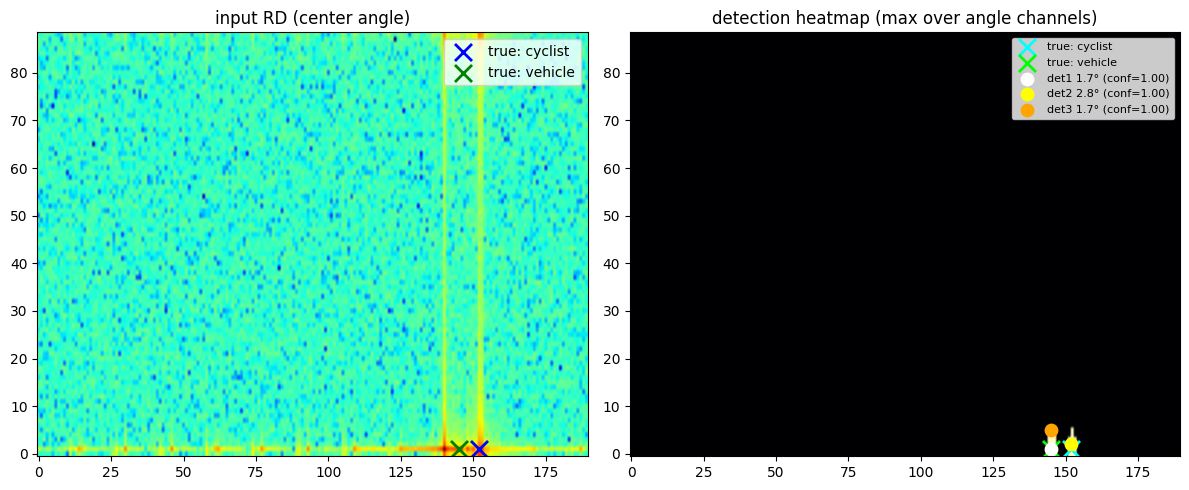

=== sample 30 ===
[detection 1] angle=1.7° d=1, r=164, conf=1.000
[detection 2] angle=2.8° d=1, r=159, conf=0.999
[detection 3] angle=2.8° d=1, r=157, conf=0.976
[detection 4] angle=1.7° d=5, r=164, conf=0.815
[true] cyclist=(1,158,2.9234826320697187)  vehicle=(1,163,1.415826906653283)


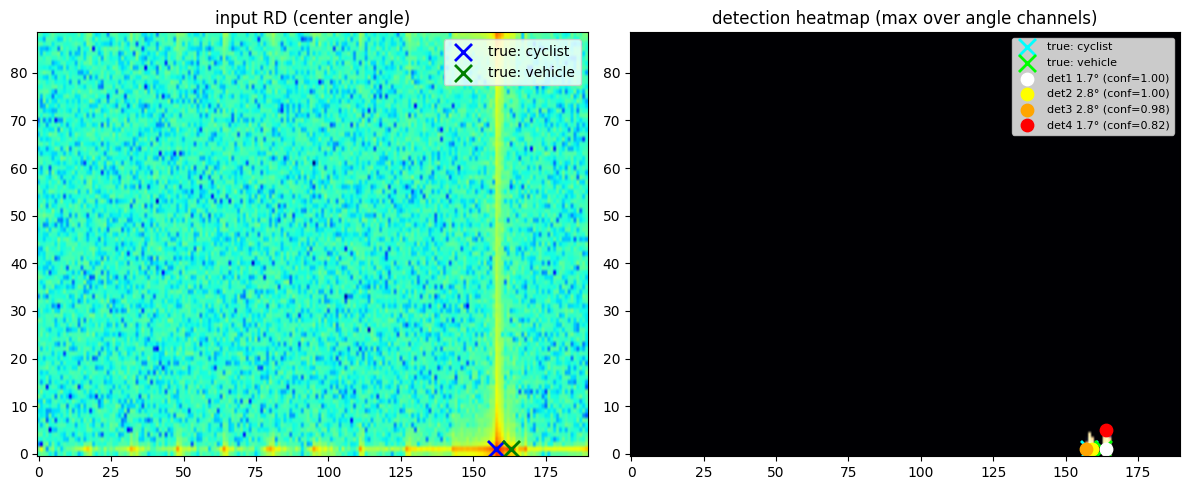

In [19]:
def show_prediction(sample_idx=0):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    peaks = decode_peaks_from_logits(logits.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    cy_true_a = float(row["cyclist_true_angle_deg"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])
    ve_true_a = float(row["vehicle_true_angle_deg"])

    print(f"=== sample {sample_idx} ===")
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        print(f"[detection {j+1}] angle={FIXED_ANGLES[pk_ch]:.1f}° d={pk_d}, r={pk_r}, conf={pk_c:.3f}")
    print(f"[true] cyclist=({cy_true_d},{cy_true_r},{cy_true_a})  vehicle=({ve_true_d},{ve_true_r},{ve_true_a})")

    rd_db   = x[N_FIXED // 2]
    heatmap = torch.sigmoid(logits)[0].max(dim=0).values.cpu().numpy()
    colors  = ["white", "yellow", "orange", "red"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        axes[1].scatter([pk_r], [pk_d], c=colors[j % len(colors)], marker="o", s=80,
                        label=f"det{j+1} {FIXED_ANGLES[pk_ch]:.1f}° (conf={pk_c:.2f})")
    axes[1].set_title("detection heatmap (max over angle channels)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_prediction(sample_idx=15)
show_prediction(sample_idx=30)

scenario: cyclist_only
det1: angle=2.8° d=2, r=168, conf=1.0000


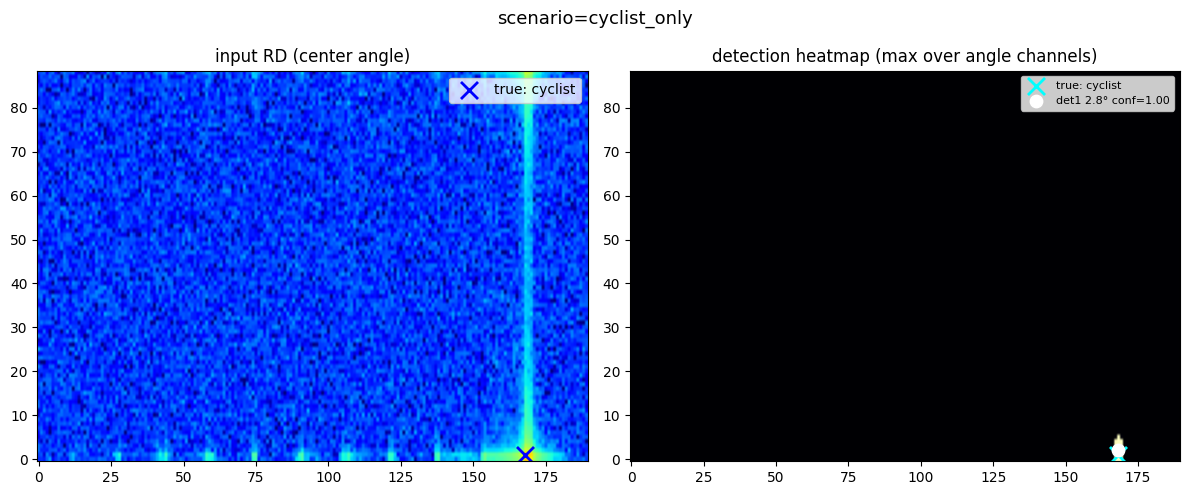

scenario: vehicle_only
det1: angle=1.7° d=2, r=100, conf=1.0000
det2: angle=1.7° d=1, r=98, conf=0.9998


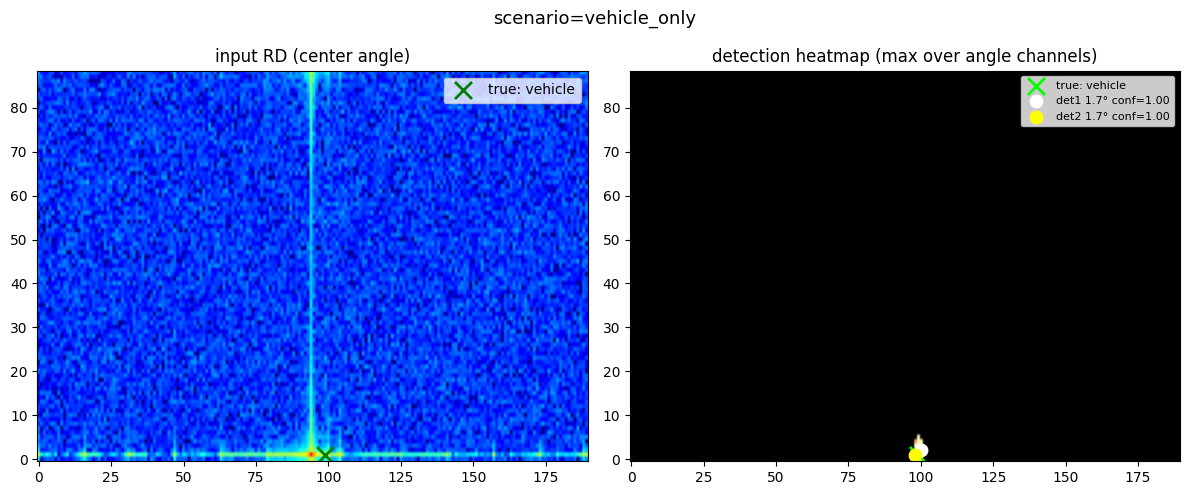

In [20]:
def show_channel_suppression(scenario, sample_idx=0):
    single_df = pd.read_csv("./learn_dataset_single_object/metadata.csv")
    single_df = single_df[single_df["scenario"] == scenario].reset_index(drop=True)
    row = single_df.iloc[sample_idx]

    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    heatmap = torch.sigmoid(logits)[0].max(dim=0).values.cpu().numpy()
    peaks = decode_peaks_from_logits(logits.cpu())

    valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
    valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0
    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"scenario: {scenario}")
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        print(f"det{j+1}: angle={FIXED_ANGLES[pk_ch]:.1f}° d={pk_d}, r={pk_r}, conf={pk_c:.4f}")

    rd_db = x[N_FIXED // 2]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"scenario={scenario}", fontsize=13)

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet", vmin=-90, vmax=0)
    if valid_cy:
        axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    if valid_cy:
        axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    colors = ["white", "yellow", "orange", "red"]
    for j, (pk_ch, pk_d, pk_r, pk_c) in enumerate(peaks):
        axes[1].scatter([pk_r], [pk_d], c=colors[j % len(colors)], marker="o", s=80,
                        label=f"det{j+1} {FIXED_ANGLES[pk_ch]:.1f}° conf={pk_c:.2f}")
    axes[1].set_title("detection heatmap (max over angle channels)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_channel_suppression("cyclist_only", sample_idx=0)
show_channel_suppression("vehicle_only", sample_idx=0)

scenario test: 31 samples

 step   cy_idx   ve_idx  r_diff    n  detail
-----------------------------------------------------------------------------------------------
    0      150      100      11    4  cy_dr=0.0  ve_dr=0.0  confs=[1.0, 1.0, 1.0, 0.994]  *FP*
    1      153      105      11    3  cy_dr=0.0  ve_dr=0.0  confs=[1.0, 1.0, 0.993]  *FP*
    2      156      110       9    2  cy<-ch7(2.8deg) r_err=+0  ve<-ch6(1.7deg) r_err=+0  confs=[1.0, 0.995]
    3      159      115       9    3  cy_dr=0.0  ve_dr=1.0  confs=[1.0, 1.0, 0.999]  *FP*
    4      162      120       9    2  cy<-ch7(2.8deg) r_err=+0  ve<-ch6(1.7deg) r_err=+0  confs=[1.0, 1.0]
    5      165      125       9    2  cy<-ch7(2.8deg) r_err=+0  ve<-ch6(1.7deg) r_err=-1  confs=[1.0, 0.992]
    6      168      130       7    2  cy<-ch7(2.8deg) r_err=+1  ve<-ch6(1.7deg) r_err=-1  confs=[1.0, 0.999]
    7      171      135       7    2  cy<-ch7(2.8deg) r_err=+1  ve<-ch6(1.7deg) r_err=+0  confs=[1.0, 1.0]
    8      174  

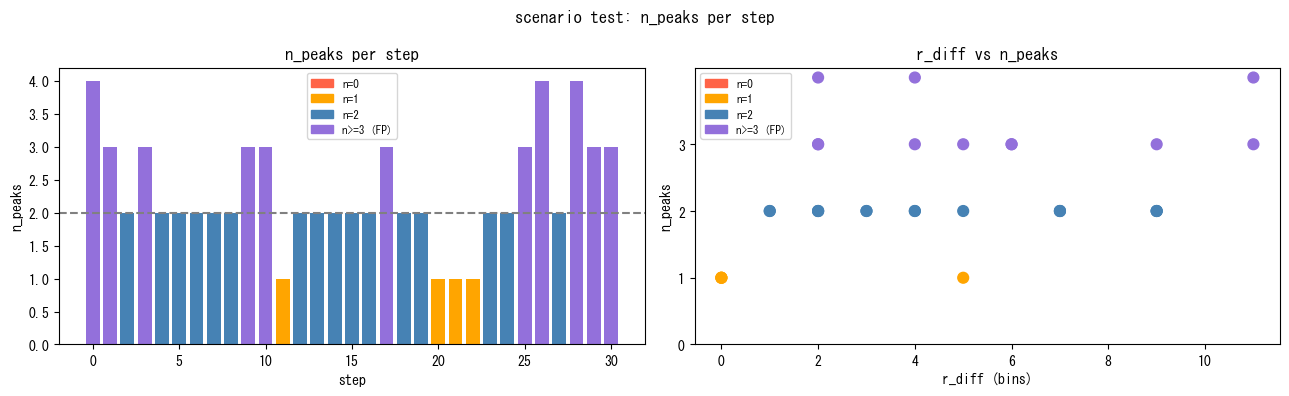

In [32]:
# === scenario test inference (by detection count) ===
import torch, matplotlib.pyplot as plt

SCENARIO_META_CSV = "./learn_dataset_scenario_test/metadata.csv"
scenario_df = pd.read_csv(SCENARIO_META_CSV)
scenario_df = scenario_df[scenario_df["valid_all"] == 1].reset_index(drop=True)
print(f"scenario test: {len(scenario_df)} samples")

rows_sc = []
for i in range(len(scenario_df)):
    row = scenario_df.iloc[i]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())

    cy_r = int(row["cyclist_true_r_idx"]); ve_r = int(row["vehicle_true_r_idx"])
    n = len(peaks)
    cy_min_dr = min(abs(p[2]-cy_r) for p in peaks) if peaks else 999
    ve_min_dr = min(abs(p[2]-ve_r) for p in peaks) if peaks else 999
    confs = [round(p[3], 3) for p in peaks]

    rows_sc.append({
        "step":      i,
        "cy_idx":    int(row["source_index_cyclist"]),
        "ve_idx":    int(row["source_index_vehicle"]),
        "cy_r":      cy_r,
        "ve_r":      ve_r,
        "r_diff":    abs(cy_r - ve_r),
        "n_peaks":   n,
        "cy_min_dr": cy_min_dr,
        "ve_min_dr": ve_min_dr,
        "confs":     confs,
        "peaks":     peaks,
    })

sc_df = pd.DataFrame(rows_sc)

print(f"\n{'step':>5}  {'cy_idx':>7}  {'ve_idx':>7}  {'r_diff':>6}  {'n':>3}  detail")
print("-" * 95)
for _, r in sc_df.iterrows():
    n = int(r['n_peaks'])
    step = int(r['step'])
    cy_r = int(r['cy_r']); ve_r = int(r['ve_r'])
    peaks = r['peaks']
    prefix = f"{step:>5}  {int(r['cy_idx']):>7}  {int(r['ve_idx']):>7}  {int(r['r_diff']):>6}  {n:>3}"

    if n == 0:
        print(f"{prefix}  no detection")

    elif n == 1:
        ch, d, pr, conf = peaks[0]
        print(f"{prefix}  single detection: "
              f"ch={ch}({FIXED_ANGLES[ch]:.1f}deg) d={d} r={pr} conf={conf:.3f}  "
              f"[cy_r_err={pr-cy_r:+d}, ve_r_err={pr-ve_r:+d}]")

    elif n == 2:
        p1, p2 = peaks[0], peaks[1]
        # r indexが近いものでマッチング (最適割り当て)
        cost_a = abs(p1[2] - cy_r) + abs(p2[2] - ve_r)
        cost_b = abs(p1[2] - ve_r) + abs(p2[2] - cy_r)
        cy_p, ve_p = (p1, p2) if cost_a <= cost_b else (p2, p1)
        print(f"{prefix}  "
              f"cy<-ch{cy_p[0]}({FIXED_ANGLES[cy_p[0]]:.1f}deg) r_err={cy_p[2]-cy_r:+d}  "
              f"ve<-ch{ve_p[0]}({FIXED_ANGLES[ve_p[0]]:.1f}deg) r_err={ve_p[2]-ve_r:+d}  "
              f"confs={[round(p[3],3) for p in peaks]}")

    else:
        print(f"{prefix}  cy_dr={r['cy_min_dr']:.1f}  ve_dr={r['ve_min_dr']:.1f}  "
              f"confs={r['confs']}  *FP*")

n0  = (sc_df["n_peaks"] == 0).sum()
n1  = (sc_df["n_peaks"] == 1).sum()
n2  = (sc_df["n_peaks"] == 2).sum()
n3p = (sc_df["n_peaks"] >= 3).sum()
total = len(sc_df)
print(f"\n=== detection count ===")
print(f"n=0  (missed both) :   {n0:>2}/{total} ({n0/total*100:.1f}%)")
print(f"n=1  (missed one)  :   {n1:>2}/{total} ({n1/total*100:.1f}%)")
print(f"n=2  (normal)      :   {n2:>2}/{total} ({n2/total*100:.1f}%)")
print(f"n>=3 (has FP)      :   {n3p:>2}/{total} ({n3p/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("scenario test: n_peaks per step")

colors_map = {0: "tomato", 1: "orange", 2: "steelblue"}
bar_colors = ["mediumpurple" if n >= 3 else colors_map.get(n, "steelblue") for n in sc_df["n_peaks"]]
axes[0].bar(sc_df["step"], sc_df["n_peaks"], color=bar_colors)
axes[0].axhline(2, color="gray", linestyle="--", label="expected n=2")
axes[0].set_xlabel("step"); axes[0].set_ylabel("n_peaks")
axes[0].set_title("n_peaks per step")
from matplotlib.patches import Patch
legend_els = [Patch(color=colors_map[k], label=f"n={k}") for k in [0,1,2]]
legend_els += [Patch(color="mediumpurple", label="n>=3 (FP)")]
axes[0].legend(handles=legend_els, fontsize=8)

scatter_colors = ["mediumpurple" if n >= 3 else colors_map.get(n, "steelblue") for n in sc_df["n_peaks"]]
axes[1].scatter(sc_df["r_diff"], sc_df["n_peaks"], c=scatter_colors, s=60, zorder=3)
axes[1].set_xlabel("r_diff (bins)"); axes[1].set_ylabel("n_peaks")
axes[1].set_title("r_diff vs n_peaks")
axes[1].set_yticks([0, 1, 2, 3])
axes[1].legend(handles=legend_els, fontsize=8)

plt.tight_layout()
plt.show()


In [28]:
# === n=2ケースの推定精度 (r/d/angle RMSE) ===
# sc_dfはscenario_evalセルで生成済みであること

import numpy as np

rows_rmse = []
for _, r in sc_df.iterrows():
    if int(r['n_peaks']) != 2:
        continue
    peaks = r['peaks']
    cy_r = int(r['cy_r']); ve_r = int(r['ve_r'])

    # r近傍でマッチング (scenario_evalと同じ最適割り当て)
    p1, p2 = peaks[0], peaks[1]
    cost_a = abs(p1[2] - cy_r) + abs(p2[2] - ve_r)
    cost_b = abs(p1[2] - ve_r) + abs(p2[2] - cy_r)
    cy_p, ve_p = (p1, p2) if cost_a <= cost_b else (p2, p1)

    step = int(r['step'])
    row = scenario_df.iloc[step]
    cy_true_angle = float(row['cyclist_true_angle_deg']) if 'cyclist_true_angle_deg' in row.index else float('nan')
    ve_true_angle = float(row['vehicle_true_angle_deg'])  if 'vehicle_true_angle_deg'  in row.index else float('nan')

    rows_rmse.append({
        'step':         step,
        'cy_r_err':     cy_p[2] - cy_r,
        'cy_d_err':     cy_p[1] - int(row['cyclist_true_d_idx']),
        'cy_angle_err': FIXED_ANGLES[cy_p[0]] - cy_true_angle,
        've_r_err':     ve_p[2] - ve_r,
        've_d_err':     ve_p[1] - int(row['vehicle_true_d_idx']),
        've_angle_err': FIXED_ANGLES[ve_p[0]] - ve_true_angle,
    })

rmse_df = pd.DataFrame(rows_rmse)
n2 = len(rmse_df)

def rmse(col): return float(np.sqrt((col ** 2).mean()))

print(f"n=2 ケース: {n2} サンプル  (angle grid spacing = {FIXED_ANGLES[1]-FIXED_ANGLES[0]:.2f} deg)")
print()
print(f"{'':12}  {'r-RMSE':>8}  {'d-RMSE':>8}  {'angle-RMSE':>12}  {'angle-bias':>12}")
print("-" * 60)
print(f"{'cyclist':12}  {rmse(rmse_df.cy_r_err):>8.3f}  {rmse(rmse_df.cy_d_err):>8.3f}  "
      f"{rmse(rmse_df.cy_angle_err):>12.3f}  {rmse_df.cy_angle_err.mean():>+12.3f}")
print(f"{'vehicle':12}  {rmse(rmse_df.ve_r_err):>8.3f}  {rmse(rmse_df.ve_d_err):>8.3f}  "
      f"{rmse(rmse_df.ve_angle_err):>12.3f}  {rmse_df.ve_angle_err.mean():>+12.3f}")
print()
print(f"※ angle-RMSE < {FIXED_ANGLES[1]-FIXED_ANGLES[0]:.2f} deg でグリッド間隔以下の推定精度")


n=2 ケース: 7 サンプル  (angle grid spacing = 1.11 deg)

                r-RMSE    d-RMSE    angle-RMSE    angle-bias
------------------------------------------------------------
cyclist          0.756     0.655         0.782        -0.679
vehicle          0.000     1.558         0.649        -0.373

※ angle-RMSE < 1.11 deg でグリッド間隔以下の推定精度


In [29]:
# === FP詳細分析: 誤検出ピークの内訳 (角度重複 vs 空間FP) ===

FP_STEPS = [i for i, r in sc_df.iterrows() if r["n_peaks"] >= 3]

print(f"FP steps ({len(FP_STEPS)}件): {FP_STEPS}\n")
print(f"{'step':>5}  {'cy_r':>5}  {'ve_r':>5}  "
      f"{'#':>3}  {'ch':>3}  {'d':>4}  {'r':>4}  {'conf':>6}  label")
print("-" * 60)

for step in FP_STEPS:
    row = scenario_df.iloc[step]
    npz_path = os.path.normpath(os.path.join(".", row["file"]))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())

    cy_r = int(row["cyclist_true_r_idx"]);  cy_d = int(row["cyclist_true_d_idx"])
    ve_r = int(row["vehicle_true_r_idx"]);  ve_d = int(row["vehicle_true_d_idx"])

    for j, (ch, d, r, conf) in enumerate(peaks):
        # 各ピークをcy/ve/FPに分類
        cy_hit = abs(d - cy_d) <= D_TOL and abs(r - cy_r) <= R_TOL
        ve_hit = abs(d - ve_d) <= D_TOL and abs(r - ve_r) <= R_TOL
        label = "cy" if cy_hit else ("ve" if ve_hit else "FP")
        marker = " <-- FP" if label == "FP" else ""
        print(f"{step:>5}  {cy_r:>5}  {ve_r:>5}  "
              f"{j+1:>3}  {ch:>3}  {d:>4}  {r:>4}  {conf:.3f}  {label}{marker}")
    print()

# --- FPピークの角度チャネル分布 ---
print("=== FPピークのch分布 ===")
fp_chs = []
for step in FP_STEPS:
    row = scenario_df.iloc[step]
    npz_path = os.path.normpath(os.path.join(".", row["file"]))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())
    cy_r = int(row["cyclist_true_r_idx"]); cy_d = int(row["cyclist_true_d_idx"])
    ve_r = int(row["vehicle_true_r_idx"]); ve_d = int(row["vehicle_true_d_idx"])
    for ch, d, r, conf in peaks:
        cy_hit = abs(d - cy_d) <= D_TOL and abs(r - cy_r) <= R_TOL
        ve_hit = abs(d - ve_d) <= D_TOL and abs(r - ve_r) <= R_TOL
        if not cy_hit and not ve_hit:
            fp_chs.append(ch)

import collections
ch_counts = collections.Counter(fp_chs)
print(f"FPピーク総数: {len(fp_chs)}")
for ch in sorted(ch_counts):
    print(f"  ch{ch} ({FIXED_ANGLES[ch]:.1f}deg): {ch_counts[ch]}件")

FP steps (23件): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 15, 17, 18, 19, 23, 25, 26, 27, 28, 29, 30]

 step   cy_r   ve_r    #   ch     d     r    conf  label
------------------------------------------------------------
    0    130    141    1    6     1   140  1.000  ve
    0    130    141    2    7     2   130  1.000  cy
    0    130    141    3    6     1   142  1.000  ve
    0    130    141    4    6     5   141  0.994  FP <-- FP

    1    129    140    1    6     1   140  1.000  ve
    1    129    140    2    7     2   129  1.000  cy
    1    129    140    3    6     5   140  0.993  FP <-- FP

    2    129    138    1    6     1   138  1.000  ve
    2    129    138    2    7     2   129  0.995  cy
    2    129    138    3    6     5   138  0.975  FP <-- FP

    3    128    137    1    6     2   138  1.000  ve
    3    128    137    2    6     2   136  1.000  ve
    3    128    137    3    7     2   128  0.999  cy

    4    127    136    1    6     1   136  1.000  ve
    4    127  

In [24]:
# === angle channel heatmaps ===
def show_angle_heatmaps(sample_idx=0, dataset_df=scenario_df):
    row = dataset_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    data = np.load(npz_path)
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    heatmaps = torch.sigmoid(logits)[0].cpu().numpy()  # (N_FIXED, H, W)
    peaks = decode_peaks_from_logits(logits.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])
    cy_angle = float(data["cyclist_true_angle_deg"]) if "cyclist_true_angle_deg" in data else float("nan")
    ve_angle = float(data["vehicle_true_angle_deg"]) if "vehicle_true_angle_deg" in data else float("nan")

    print(f"sample {sample_idx}")
    print(f"  [true] cyclist : d={cy_true_d}, r={cy_true_r}, angle={cy_angle:.2f}deg")
    print(f"  [true] vehicle : d={ve_true_d}, r={ve_true_r}, angle={ve_angle:.2f}deg")
    print(f"  [detected] {len(peaks)} peaks:")
    for j, (ch, d, r, conf) in enumerate(peaks):
        cy_hit = abs(d - cy_true_d) <= D_TOL and abs(r - cy_true_r) <= R_TOL
        ve_hit = abs(d - ve_true_d) <= D_TOL and abs(r - ve_true_r) <= R_TOL
        label = "cy" if cy_hit else ("ve" if ve_hit else "FP")
        print(f"    det{j+1}: ch={ch} ({FIXED_ANGLES[ch]:.1f}deg)  d={d}, r={r}  conf={conf:.3f}  [{label}]")
    
    """
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle(f"sample {sample_idx} — per-angle heatmaps", fontsize=13)

    for i, ax in enumerate(axes.flat):
        im = ax.imshow(heatmaps[i], aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=1)
        ax.set_title(f"ch{i} {FIXED_ANGLES[i]:.1f}deg  max={heatmaps[i].max():.2f}")
        ax.set_xlabel("range")
        ax.set_ylabel("doppler")
        plt.colorbar(im, ax=ax, fraction=0.03)

    plt.tight_layout()
    plt.show()
    """
#show_angle_heatmaps(sample_idx=8)    
for i in range(16,21):
    show_angle_heatmaps(sample_idx=i)

sample 16
  [true] cyclist : d=1, r=118, angle=3.29deg
  [true] vehicle : d=1, r=120, angle=1.71deg
  [detected] 2 peaks:
    det1: ch=6 (1.7deg)  d=1, r=120  conf=1.000  [cy]
    det2: ch=6 (1.7deg)  d=5, r=120  conf=0.998  [FP]
sample 17
  [true] cyclist : d=1, r=117, angle=3.30deg
  [true] vehicle : d=1, r=119, angle=1.72deg
  [detected] 3 peaks:
    det1: ch=6 (1.7deg)  d=2, r=120  conf=1.000  [cy]
    det2: ch=6 (1.7deg)  d=1, r=118  conf=1.000  [cy]
    det3: ch=7 (2.8deg)  d=1, r=116  conf=1.000  [cy]
sample 18
  [true] cyclist : d=1, r=116, angle=3.31deg
  [true] vehicle : d=1, r=118, angle=1.73deg
  [detected] 3 peaks:
    det1: ch=6 (1.7deg)  d=1, r=118  conf=1.000  [cy]
    det2: ch=8 (3.9deg)  d=1, r=116  conf=1.000  [cy]
    det3: ch=6 (1.7deg)  d=5, r=118  conf=0.988  [FP]
sample 19
  [true] cyclist : d=1, r=116, angle=3.31deg
  [true] vehicle : d=1, r=117, angle=1.74deg
  [detected] 3 peaks:
    det1: ch=6 (1.7deg)  d=1, r=117  conf=1.000  [cy]
    det2: ch=8 (3.9deg)  d

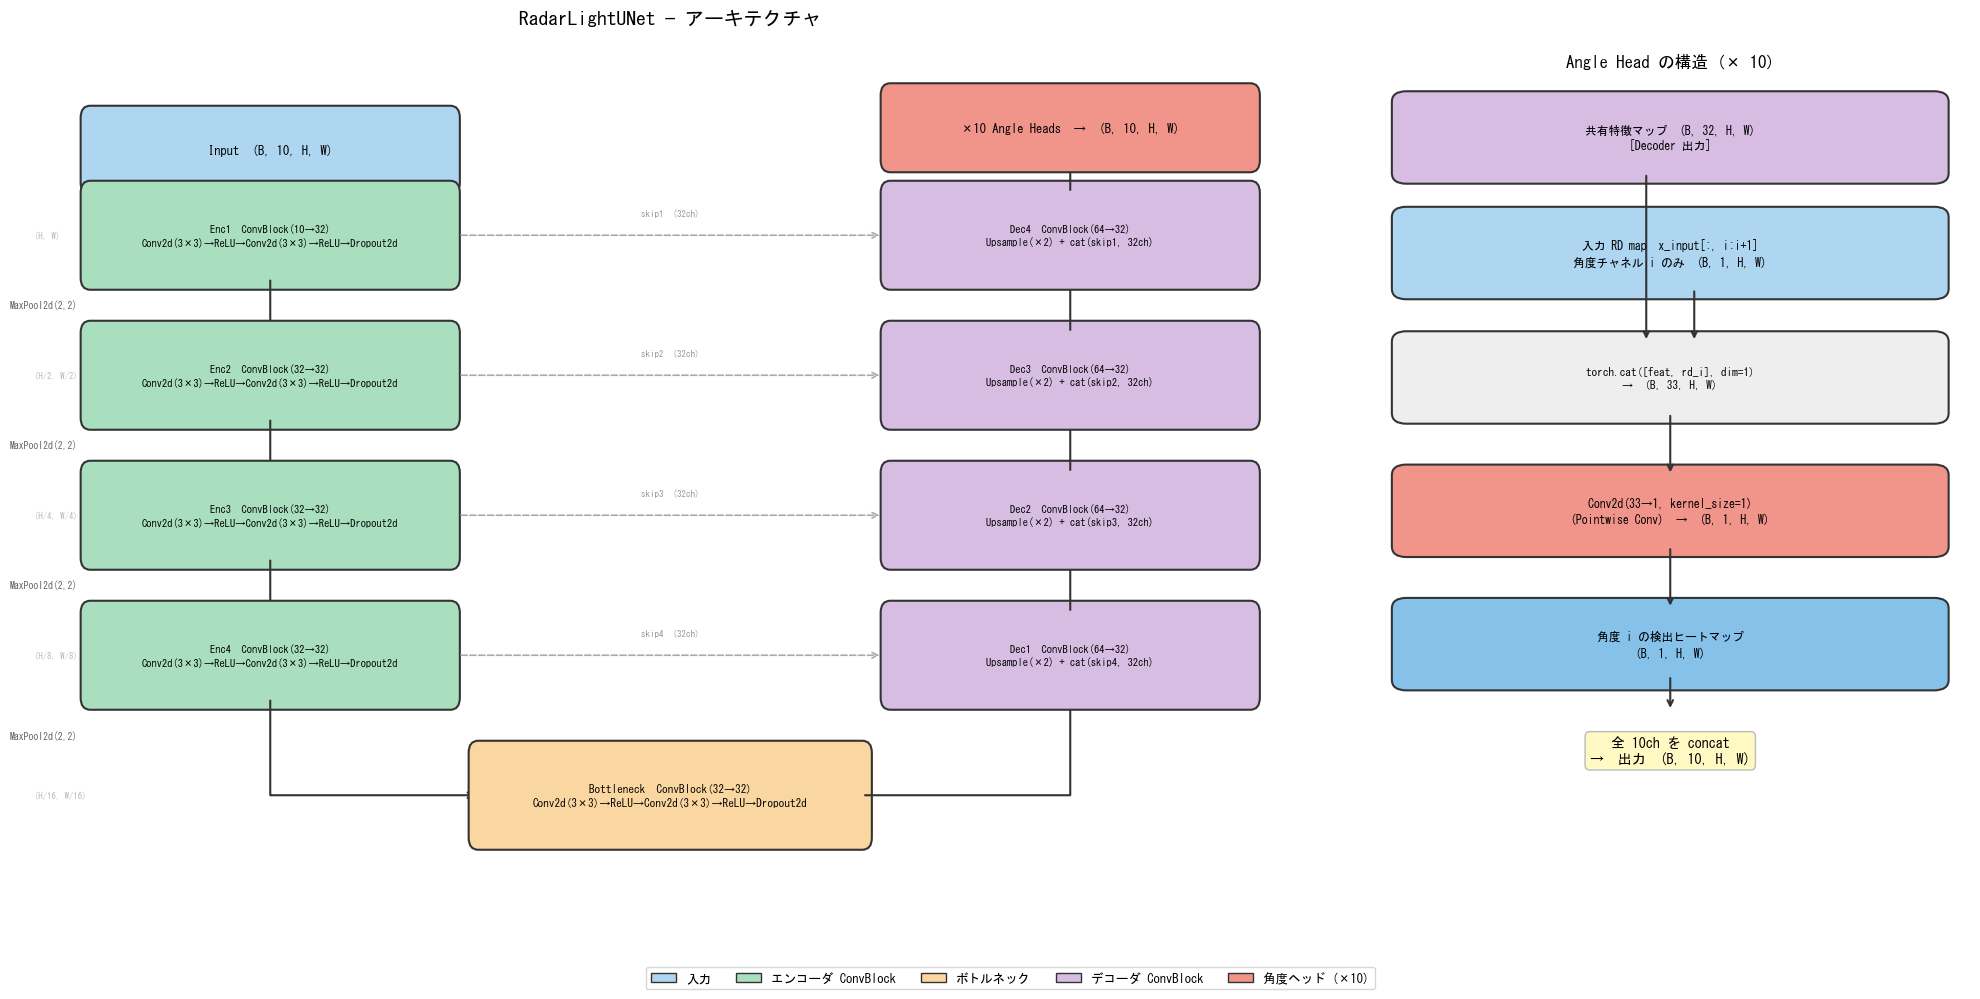

architecture_diagram.png に保存しました


In [25]:
# === RadarLightUNet アーキテクチャ図 ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# Windows で日本語フォントを設定
plt.rcParams['font.family'] = 'MS Gothic'

fig = plt.figure(figsize=(20, 10))
ax  = fig.add_axes([0.01, 0.08, 0.64, 0.88])   # UNet バックボーン
axh = fig.add_axes([0.68, 0.12, 0.30, 0.80])   # 角度ヘッド詳細

C_IN   = "#AED6F1"
C_ENC  = "#A9DFBF"
C_BOT  = "#FAD7A0"
C_DEC  = "#D7BDE2"
C_HEAD = "#F1948A"
C_OUT  = "#85C1E9"

def box(a, cx, cy, w, h, txt, color, fs=8):
    r = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                        boxstyle="round,pad=0.12",
                        fc=color, ec="#333", lw=1.5, zorder=3)
    a.add_patch(r)
    a.text(cx, cy, txt, ha='center', va='center', fontsize=fs,
           fontweight='bold', zorder=4, linespacing=1.4)

def arr(a, x1, y1, x2, y2, color='#333', lw=1.5, ls='solid', cs='arc3'):
    a.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                               linestyle=ls, connectionstyle=cs))

# ─── UNet バックボーン ────────────────────────────────────────
ax.set_xlim(0, 16)
ax.set_ylim(2.0, 10.8)
ax.axis('off')
ax.set_title('RadarLightUNet — アーキテクチャ', fontsize=14, fontweight='bold', pad=8)

EX  = 3.0    # エンコーダ中心 x
DX  = 13.0   # デコーダ中心 x
BW  = 4.5    # ブロック幅
BH  = 0.85   # ブロック高さ
BNW = 4.8    # ボトルネック幅
YS  = [8.8, 7.4, 6.0, 4.6]   # 各レベルの y 座標
BY, BX = 3.2, 8.0             # ボトルネック y, x

# 入力
box(ax, EX, 9.65, BW, 0.65, 'Input  (B, 10, H, W)', C_IN, fs=9)
arr(ax, EX, 9.33, EX, YS[0]+BH/2)

# エンコーダ
enc_txts = [
    'Enc1  ConvBlock(10→32)\nConv2d(3×3)→ReLU→Conv2d(3×3)→ReLU→Dropout2d',
    'Enc2  ConvBlock(32→32)\nConv2d(3×3)→ReLU→Conv2d(3×3)→ReLU→Dropout2d',
    'Enc3  ConvBlock(32→32)\nConv2d(3×3)→ReLU→Conv2d(3×3)→ReLU→Dropout2d',
    'Enc4  ConvBlock(32→32)\nConv2d(3×3)→ReLU→Conv2d(3×3)→ReLU→Dropout2d',
]
for i, (txt, y) in enumerate(zip(enc_txts, YS)):
    box(ax, EX, y, BW, BH, txt, C_ENC, fs=7.5)
    if i < 3:
        arr(ax, EX, y-BH/2, EX, YS[i+1]+BH/2)
        ax.text(EX - BW/2 - 0.15,
                (y - BH/2 + YS[i+1] + BH/2) / 2,
                'MaxPool2d(2,2)', ha='right', va='center', fontsize=7, color='#666')

# Enc4 → Bottleneck (L字: 下→右)
ax.text(EX - BW/2 - 0.15, YS[3] - BH/2 - 0.38,
        'MaxPool2d(2,2)', ha='right', va='center', fontsize=7, color='#666')
arr(ax, EX, YS[3]-BH/2, BX-BNW/2, BY,
    cs='angle,angleA=-90,angleB=180,rad=0.1')

# ボトルネック
box(ax, BX, BY, BNW, BH,
    'Bottleneck  ConvBlock(32→32)\nConv2d(3×3)→ReLU→Conv2d(3×3)→ReLU→Dropout2d',
    C_BOT, fs=8)

# Bottleneck → Dec1 (L字: 右→上)
arr(ax, BX+BNW/2, BY, DX, YS[3]-BH/2,
    cs='angle,angleA=0,angleB=-90,rad=0.1')

# デコーダ
dec_txts = [
    'Dec1  ConvBlock(64→32)\nUpsample(×2) + cat(skip4, 32ch)',
    'Dec2  ConvBlock(64→32)\nUpsample(×2) + cat(skip3, 32ch)',
    'Dec3  ConvBlock(64→32)\nUpsample(×2) + cat(skip2, 32ch)',
    'Dec4  ConvBlock(64→32)\nUpsample(×2) + cat(skip1, 32ch)',
]
dec_ys = list(reversed(YS))
for i, (txt, y) in enumerate(zip(dec_txts, dec_ys)):
    box(ax, DX, y, BW, BH, txt, C_DEC, fs=7.5)
    if i < 3:
        arr(ax, DX, y+BH/2, DX, dec_ys[i+1]-BH/2)

# Dec4 → 角度ヘッド
out_y = YS[0] + BH/2 + 0.65
arr(ax, DX, YS[0]+BH/2, DX, out_y-0.28)
box(ax, DX, out_y, BW, 0.65, '×10 Angle Heads  →  (B, 10, H, W)', C_HEAD, fs=9)

# スキップ接続 (破線)
for i, y in enumerate(YS):
    xl = EX + BW/2 + 0.1
    xr = DX - BW/2 - 0.1
    ax.annotate('', xy=(xr, y), xytext=(xl, y),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.2,
                                linestyle='dashed'))
    ax.text((xl+xr)/2, y+0.18, f'skip{i+1}  (32ch)',
            ha='center', va='bottom', fontsize=6.5, color='#999')

# 解像度ラベル (左端)
res_lbls = ['(H, W)', '(H/2, W/2)', '(H/4, W/4)', '(H/8, W/8)']
for y, rl in zip(YS, res_lbls):
    ax.text(0.05, y, rl, ha='left', va='center',
            fontsize=6.2, color='#bbb', style='italic')
ax.text(0.05, BY, '(H/16, W/16)', ha='left', va='center',
        fontsize=6.2, color='#bbb', style='italic')

# ─── 角度ヘッド詳細 ──────────────────────────────────────────
axh.set_xlim(0, 5)
axh.set_ylim(0.5, 9.5)
axh.axis('off')
axh.set_title('Angle Head の構造 (× 10)', fontsize=12, fontweight='bold', pad=6)

def hbox(cy, txt, color, fs=8.5):
    box(axh, 2.5, cy, 4.4, 0.8, txt, color, fs)

hbox(8.8, '共有特徴マップ  (B, 32, H, W)\n[Decoder 出力]', C_DEC)
hbox(7.5, '入力 RD map  x_input[:, i:i+1]\n角度チャネル i のみ  (B, 1, H, W)', C_IN)
hbox(6.1, 'torch.cat([feat, rd_i], dim=1)\n→  (B, 33, H, W)', '#EEEEEE', fs=8)

# 2本の収束矢印 (共有特徴・入力 → cat)
axh.annotate('', xy=(2.3, 6.5), xytext=(2.3, 8.4),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
axh.annotate('', xy=(2.7, 6.5), xytext=(2.7, 7.1),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

hbox(4.6, 'Conv2d(33→1, kernel_size=1)\n(Pointwise Conv)  →  (B, 1, H, W)', C_HEAD)
axh.annotate('', xy=(2.5, 5.0), xytext=(2.5, 5.7),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

hbox(3.1, '角度 i の検出ヒートマップ\n(B, 1, H, W)', C_OUT)
axh.annotate('', xy=(2.5, 3.5), xytext=(2.5, 4.2),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

axh.text(2.5, 1.9, '全 10ch を concat\n→  出力  (B, 10, H, W)',
         ha='center', va='center', fontsize=10, fontweight='bold',
         bbox=dict(fc='#FFF9C4', ec='#BBB', boxstyle='round,pad=0.35'))
axh.annotate('', xy=(2.5, 2.35), xytext=(2.5, 2.75),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# ─── 凡例 ────────────────────────────────────────────────────
patches = [
    mpatches.Patch(fc=C_IN,   ec='#333', label='入力'),
    mpatches.Patch(fc=C_ENC,  ec='#333', label='エンコーダ ConvBlock'),
    mpatches.Patch(fc=C_BOT,  ec='#333', label='ボトルネック'),
    mpatches.Patch(fc=C_DEC,  ec='#333', label='デコーダ ConvBlock'),
    mpatches.Patch(fc=C_HEAD, ec='#333', label='角度ヘッド (×10)'),
]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, 0.0))

plt.savefig('architecture_diagram.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("architecture_diagram.png に保存しました")

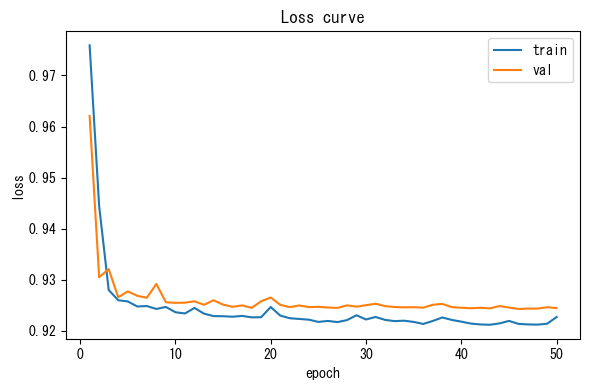

In [26]:
# === 学習曲線 ===
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
ax.plot(hist_df["epoch"], hist_df["val_loss"],   label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Loss curve")
ax.legend()

plt.tight_layout()
plt.show()